In [25]:
import pandas as pd
import seaborn as sns
import numpy as np
sns.set(rc={'figure.figsize': (11.7, 8.27)})
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

In [26]:
data = pd.read_csv('student-mat.csv')
print(data)

    school gender  age address famsize Pstatus  Medu  Fedu      Mjob  \
0       GP      F   18       U     GT3       A     4     4   at_home   
1       GP      F   17       U     GT3       T     1     1   at_home   
2       GP      F   15       U     LE3       T     1     1   at_home   
3       GP      F   15       U     GT3       T     4     2    health   
4       GP      F   16       U     GT3       T     3     3     other   
..     ...    ...  ...     ...     ...     ...   ...   ...       ...   
390     MS      M   20       U     LE3       A     2     2  services   
391     MS      M   17       U     LE3       T     3     1  services   
392     MS      M   21       R     GT3       T     1     1     other   
393     MS      M   18       R     LE3       T     3     2  services   
394     MS      M   19       U     LE3       T     1     1     other   

         Fjob  ... higher internet  romantic  famrel  freetime goout health  \
0     teacher  ...    yes       no        no       4    

<Axes: xlabel='G3', ylabel='Count'>

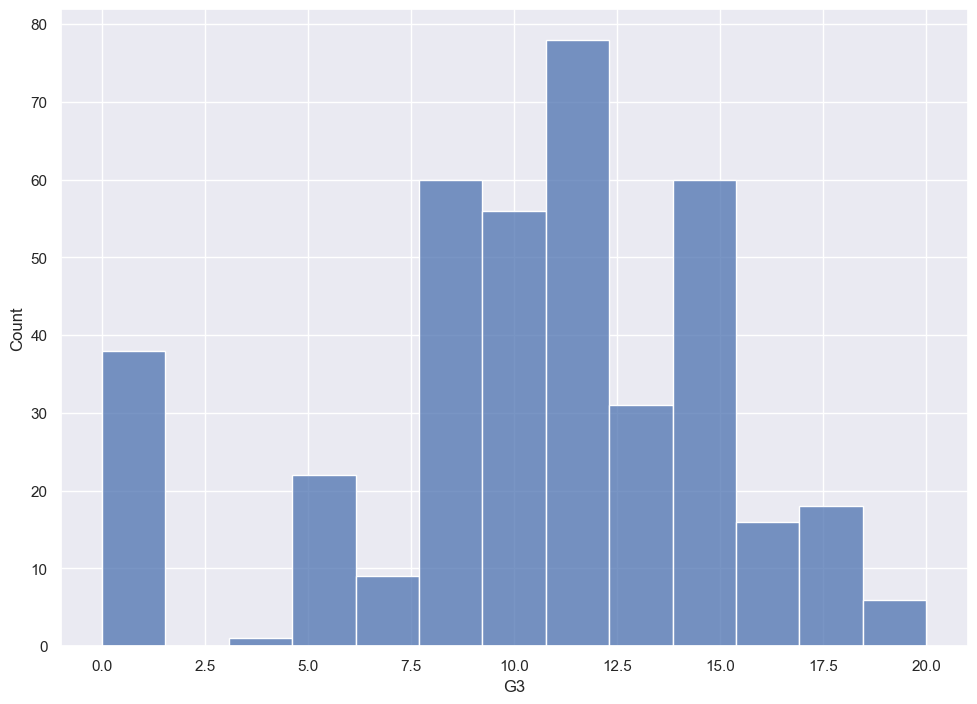

In [27]:
sns.histplot(data['G3'])

In [28]:
data = data[data['G3'] != 0] 

X = data.drop(columns=['G3'])
y = data['G3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=50, random_state=0)

X_y_train = X_train.copy(deep=True)
X_y_train['y'] = y_train

print(X_y_train.corr(numeric_only=True))


                 age      Medu      Fedu  traveltime  studytime  failures  \
age         1.000000 -0.143667 -0.152028    0.124947  -0.012044  0.265867   
Medu       -0.143667  1.000000  0.622469   -0.189125   0.059405 -0.217911   
Fedu       -0.152028  0.622469  1.000000   -0.194381  -0.031392 -0.265805   
traveltime  0.124947 -0.189125 -0.194381    1.000000  -0.105084  0.131414   
studytime  -0.012044  0.059405 -0.031392   -0.105084   1.000000 -0.136720   
failures    0.265867 -0.217911 -0.265805    0.131414  -0.136720  1.000000   
famrel      0.105719 -0.005481 -0.031753   -0.002823   0.063829 -0.020901   
freetime    0.018381 -0.021037 -0.054498   -0.007708  -0.132218  0.133293   
goout       0.127471  0.080858  0.029325    0.062239  -0.018720  0.195804   
health     -0.066960 -0.030022 -0.007715    0.016959  -0.087165  0.042964   
absences    0.232719  0.052977 -0.015996    0.028547  -0.098216  0.161519   
G1         -0.058061  0.180870  0.160996   -0.119743   0.156326 -0.326272   

<Axes: >

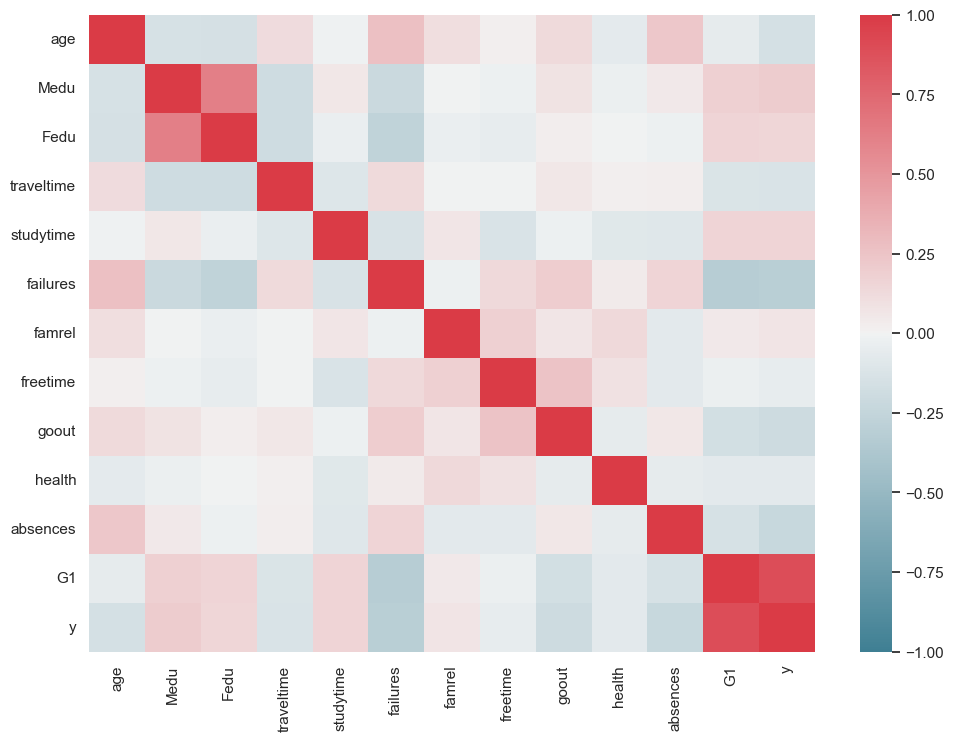

In [29]:
sns.heatmap(X_y_train.corr(numeric_only=True),
            vmin=-1, vmax=1,
            cmap=sns.diverging_palette(220, 10, as_cmap=True))

In [30]:
corry = X_y_train.corr(numeric_only=True)['y']
main_facts = corry[(corry > 0.1) | (corry < -0.1) ]
print(main_facts.index.tolist())

['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'goout', 'absences', 'G1', 'y']


In [31]:
main_facts = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'goout', 'absences', 'G1']


In [32]:
categorical_columns = data.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_columns = data.select_dtypes(include=[np.number]).columns.tolist()
print("Категориальные колонки:", categorical_columns)
print("Численные колонки:", numerical_columns)

Категориальные колонки: ['school', 'gender', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Численные колонки: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'health', 'absences', 'G1', 'G3']


In [33]:
for fact in categorical_columns:
    taby = X_y_train.groupby(fact, as_index=False).agg({'y': 'mean'})['y']
    if abs(min(taby) - max(taby)) > 1.5:
        print(fact)
    

Mjob
Fjob
schoolsup
higher


In [34]:
interesting_categorical_factors = ['Mjob', 'Fjob', 'schoolsup', 'higher']

In [35]:
from category_encoders.target_encoder import TargetEncoder

mjob_target_encoder = TargetEncoder()
mjob_target_encoder.fit(X_y_train['Mjob'], X_y_train['y'])

fjob_target_encoder = TargetEncoder()
fjob_target_encoder.fit(X_y_train['Fjob'], X_y_train['y'])

schoolsup_target_encoder = TargetEncoder()
schoolsup_target_encoder.fit(X_y_train['schoolsup'], X_y_train['y'])

higher_target_encoder = TargetEncoder()
higher_target_encoder.fit(X_y_train['higher'], X_y_train['y'])

X_y_train['Mjob_encoded'] = mjob_target_encoder.transform(X_y_train['Mjob'])
X_y_train['Fjob_encoded'] = fjob_target_encoder.transform(X_y_train['Fjob'])
X_y_train['schoolsup_encoded'] = schoolsup_target_encoder.transform(X_y_train['schoolsup'])
X_y_train['higher_encoded'] = higher_target_encoder.transform(X_y_train['higher'])


In [36]:
X_y_train

,school,gender,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,health,absences,G1,y,Mjob_encoded,Fjob_encoded,schoolsup_encoded,higher_encoded
295,GP,M,17,U,GT3,T,3,3,health,other,...,4,3,5,4,14,11,12.781907,11.339181,11.835821,11.657627
224,GP,F,16,U,GT3,T,4,4,teacher,services,...,3,2,5,0,13,14,11.734708,11.476373,11.835821,11.657627
197,GP,M,16,R,LE3,T,3,3,teacher,other,...,3,4,3,8,9,10,11.734708,11.339181,11.835821,11.657627
231,GP,M,17,R,GT3,T,2,2,other,other,...,5,2,1,4,11,11,10.963057,11.339181,11.835821,11.657627
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,1,4,1,6,6,6,10.963057,12.723082,10.094869,11.657627
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,MS,F,17,U,LE3,A,3,2,services,other,...,2,3,5,2,12,11,12.251790,11.339181,11.835821,11.657627
210,GP,F,19,U,GT3,T,3,3,other,other,...,3,3,3,10,8,8,10.963057,11.339181,11.835821,11.657627
117,GP,M,16,U,GT3,T,3,3,other,services,...,4,2,5,0,13,13,10.963057,11.476373,11.835821,11.657627
47,GP,M,16,U,GT3,T,4,3,health,services,...,2,2,2,4,19,20,12.781907,11.476373,11.835821,11.657627


In [37]:
factors_to_use = main_facts + ['Mjob_encoded', 'Fjob_encoded', 'schoolsup_encoded', 'higher_encoded']
X_train_encoded = X_y_train.copy(deep=True)
X_train_encoded = X_train_encoded[factors_to_use]

In [38]:
X_train_encoded

,age,Medu,Fedu,traveltime,studytime,failures,goout,absences,G1,Mjob_encoded,Fjob_encoded,schoolsup_encoded,higher_encoded
295,17,3,3,1,1,0,3,4,14,12.781907,11.339181,11.835821,11.657627
224,16,4,4,1,3,0,2,0,13,11.734708,11.476373,11.835821,11.657627
197,16,3,3,3,1,0,4,8,9,11.734708,11.339181,11.835821,11.657627
231,17,2,2,2,2,0,2,4,11,10.963057,11.339181,11.835821,11.657627
7,17,4,4,2,2,0,4,6,6,10.963057,12.723082,10.094869,11.657627
...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,17,3,2,2,2,0,3,2,12,12.251790,11.339181,11.835821,11.657627
210,19,3,3,1,4,0,3,10,8,10.963057,11.339181,11.835821,11.657627
117,16,3,3,2,1,0,2,0,13,10.963057,11.476373,11.835821,11.657627
47,16,4,3,1,4,0,2,4,19,12.781907,11.476373,11.835821,11.657627


In [39]:
scaler = MinMaxScaler()
scaler.fit(X_train_encoded)
X_train_scaled = scaler.transform(X_train_encoded)

In [40]:
X_train_scaled

array([[0.28571429, 0.75      , 0.75      , ..., 0.        , 1.        ,
        1.        ],
       [0.14285714, 1.        , 1.        , ..., 0.09913411, 1.        ,
        1.        ],
       [0.14285714, 0.75      , 0.75      , ..., 0.        , 1.        ,
        1.        ],
       ...,
       [0.14285714, 0.75      , 0.75      , ..., 0.09913411, 1.        ,
        1.        ],
       [0.14285714, 1.        , 0.75      , ..., 0.09913411, 1.        ,
        1.        ],
       [0.14285714, 0.5       , 0.75      , ..., 0.09913411, 1.        ,
        1.        ]])

In [41]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
model.score(X_train_scaled, y_train)

0.8296948851119444

In [42]:
X_test['Mjob_encoded'] = mjob_target_encoder.transform(X_test['Mjob'])
X_test['Fjob_encoded'] = fjob_target_encoder.transform(X_test['Fjob'])
X_test['schoolsup_encoded'] = schoolsup_target_encoder.transform(X_test['schoolsup'])
X_test['higher_encoded'] = higher_target_encoder.transform(X_test['higher'])

In [43]:
X_test_encoded = X_test[factors_to_use]
X_test_scaled = scaler.transform(X_test_encoded)
model.score(X_test_scaled, y_test)


0.7399959508706928

In [44]:
model.predict(X_test_scaled)

array([12.30592624, 11.36965841,  9.15338597, 11.93521494,  8.22350207,
        7.64184885, 10.33979692, 10.71201816, 14.81642799, 15.27962051,
       12.66433842, 12.34116969, 14.27505866, 14.02264881,  9.28011978,
       10.53859112, 13.78416141, 14.44034591, 16.09649869, 11.90037851,
        6.51552956, 15.03418091,  9.07423745, 11.09556339,  7.94461604,
       13.09373322, 12.28341998,  9.39685591, 14.26168329,  7.4270002 ,
        7.91952641,  8.23081465, 11.96355387,  8.66555215, 10.58895431,
       13.96930499, 11.85754285,  8.0538466 , 11.92359968, 18.01892306,
       14.14294755, 13.22614301, 15.50742459,  9.13266541,  7.12784188,
       13.54610981,  8.10742329,  9.24050593,  9.42132007, 13.29501671])

In [45]:
def score_model(model, X_test, y_test):
    y_preds = model.predict(X_test)
    
    errs = []
    
    for y, y_pred in zip(y_test, y_preds):
        errs.append(abs(y - y_pred))
        
    mae = sum(errs) / len(errs)
    
    mean_y_test = sum(y_test) / len(y_test)
    r2 = 1 - sum(err ** 2 for err in errs) / sum((y - mean_y_test) ** 2 for y in y_test)
    
    return mae, r2

In [46]:
score_model(model, X_test_scaled, y_test)

(1.2537788819738405, 0.7399959508706929)

In [47]:
maes = []
r2s = []

X_y_test = X_test_encoded.copy(deep=True)
X_y_test['y'] = y_test

for i in range(1000):
    X_y_sample = X_y_test.sample(len(X_y_test), replace=True)
    
    X_test_sample = X_y_sample.drop(columns=['y'])
    X_test_sample = scaler.transform(X_test_sample)
    y_test_sample = X_y_sample['y']
    
    mae_sample, r2_sample = score_model(model, X_test_sample, y_test_sample)
    
    maes.append(mae_sample)
    r2s.append(r2_sample)
maes = list(sorted(maes))
maes = maes[25:975]
print(maes[0],maes[-1])

1.0347965824389227 1.492030172717167


In [48]:
for x, y in zip(factors_to_use, model.coef_):
    print(x, round(y, 2))

age -1.66
Medu 0.66
Fedu -0.45
traveltime -0.1
studytime 0.17
failures 0.25
goout -0.5
absences -2.78
G1 13.82
Mjob_encoded 0.38
Fjob_encoded -0.08
schoolsup_encoded 0.19
higher_encoded -0.39
